# Examine the piecewise flat instantaneous (overnight, or ON) forward rate discount curve

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
from financepy.utils.date import Date
from financepy.utils.day_count import DayCountTypes
from financepy.products.rates import *
from financepy.market.curves import *
from financepy.market.curves.pwf_onf_discount_curve import PWFONFDiscountCurve
from financepy.market.curves.composite_discount_curve import CompositeDiscountCurve

In [37]:
valuation_date = Date(1, 1, 2015)

We have a vector of dates and on fwd rates

In [29]:
knot_dts = [Date(1, 1, 2015), Date(1, 6, 2016), Date(1, 12, 2017), Date(1, 4, 2018), Date(1, 8, 2019)]
ondfwd_rates = [0, 0.02, 0.04, 0.06, 0.08]
disc_curve = PWFONFDiscountCurve(valuation_date, knot_dts, ondfwd_rates, DayCountTypes.ACT_ACT_ISDA)

In [38]:
print(disc_curve)

OBJECT TYPE: PWFONFDiscountCurve
DATE: ON_FWD RATE
01-JAN-2015:   0.00000000
01-JUN-2016:   0.02000000
01-DEC-2017:   0.04000000
01-APR-2018:   0.06000000
01-AUG-2019:   0.08000000
FREQUENCY : FrequencyTypes.CONTINUOUS

OBJECT_TYPE: DiscountCurve
VALUE DATE: 01-JAN-2015
    DATES      TIMES(YRS) DISC FACTORS
 01-JAN-2015:     0.000000  1.00000000
 01-JUN-2016:     1.415301  0.97209085
 01-DEC-2017:     2.915068  0.91548918
 01-APR-2018:     3.246575  0.89745963
 01-AUG-2019:     4.580822  0.80660043
INTERPOLATION TYPE: N/A
TIME DAY COUNT TYPE: ACT_ACT_ISDA



In [39]:
for dt in knot_dts:
    df = disc_curve.df(dt)
    print(dt, df)

01-JAN-2015 0.99999999999998
01-JUN-2016 0.9720908508576973
01-DEC-2017 0.9154891844114357
01-APR-2018 0.8974596303381441
01-AUG-2019 0.8066004281107282


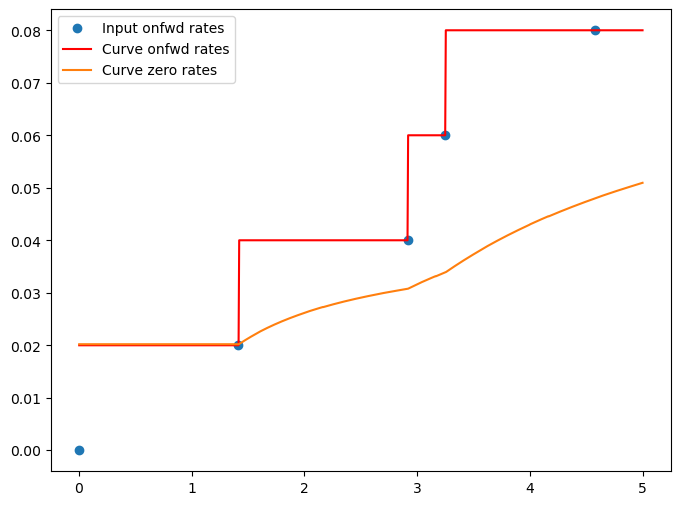

In [32]:
knot_years = disc_curve._times
tInterpValues = np.linspace(1/365, 5.0, int(5*365))
interpDates = valuation_date.add_years(tInterpValues)
fwdInterpValues = disc_curve.fwd_rate_inst(interpDates)
zerosInterpValues = disc_curve.zero_rate(interpDates)


plt.figure(figsize=(8, 6))
plt.plot(knot_years, ondfwd_rates, 'o', label="Input onfwd rates")
plt.plot(tInterpValues, fwdInterpValues, color='r', label="Curve onfwd rates")
plt.plot(tInterpValues, zerosInterpValues, label="Curve zero rates")
plt.legend(loc = 'best')
plt.show()

### Create a bump curve and apply to the base curve

First create a bump

In [33]:
bump_dates = [Date(1, 6, 2017), Date(1, 6, 2018), Date(2, 6, 2018)]
# bump_years = [DayCount(DayCountTypes.ACT_ACT_ISDA).year_frac(valuation_date, d)[0] for d in bump_dates]
bump_onfwd_rates = [0.0, 0.01, 0.00]
bump_curve = PWFONFDiscountCurve(valuation_date, bump_dates, bump_onfwd_rates)

Next apply the bump

In [34]:
bumped_curve = CompositeDiscountCurve([disc_curve, bump_curve])

Now plot base and bumped

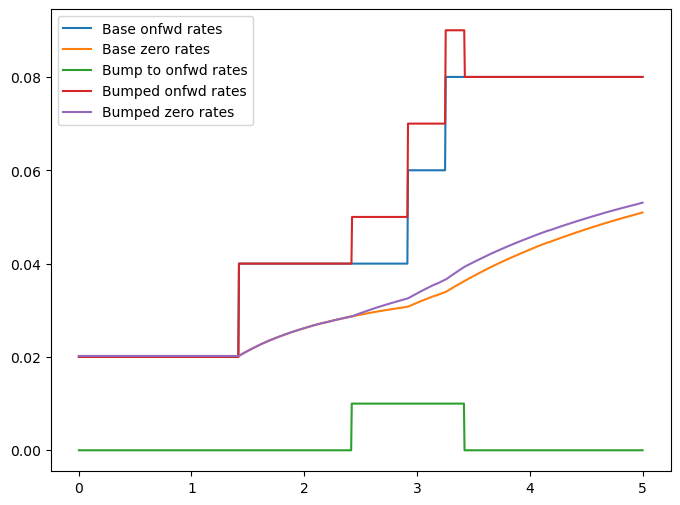

In [35]:
tInterpValues = np.linspace(1/365, 5.0, int(5*365))
interpDates = valuation_date.add_years(tInterpValues)
base_onfwd_rates = disc_curve.fwd_rate_inst(interpDates)
base_zero_rates = disc_curve.zero_rate(interpDates)

bump_onfwd_rates = bump_curve.fwd_rate_inst(interpDates)

bumped_onfwd_rates = bumped_curve.fwd_rate_inst(interpDates)
bumped_zero_rates = bumped_curve.zero_rate(interpDates)

plt.figure(figsize=(8, 6))
plt.plot(tInterpValues, base_onfwd_rates, label="Base onfwd rates")
plt.plot(tInterpValues, base_zero_rates, label="Base zero rates")

plt.plot(tInterpValues, bump_onfwd_rates, label="Bump to onfwd rates")
plt.plot(tInterpValues, bumped_onfwd_rates, label="Bumped onfwd rates")
plt.plot(tInterpValues, bumped_zero_rates, label="Bumped zero rates")

plt.legend(loc = 'best')
plt.show()